# NLP Mini Project: Traditional Text Classification Pipeline

## Project Overview

In this project, students will build a **complete traditional Natural Language Processing (NLP) machine learning pipeline** for text classification. The focus is on **classical NLP techniques** rather than deep learning.

Students will learn how to:

- Perform text preprocessing
- Apply classical NLP techniques
- Convert text into numerical features
- Train machine learning models
- Evaluate model performance
- Save preprocessing objects and trained models
- Deploy the trained model using a simple FastAPI service

---

## Learning Objectives

By completing this project, students will:

1. Understand the steps of a traditional NLP pipeline
2. Implement text preprocessing techniques
3. Convert text into vector representations (BOW / TF-IDF)
4. Train classical ML models for text classification
5. Evaluate models using proper metrics
6. Save preprocessing pipelines and models
7. Deploy the model as an API using FastAPI

---

# Dataset


### Kaggle Dataset (Optional)

Students may alternatively use an easy Kaggle dataset such as:

Spam Classification

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Task:

Classify SMS messages as:

- spam
- ham

---

# Project Requirements

Students must implement the following pipeline:

1. Data loading
2. Text preprocessing
3. Feature extraction
4. Model training
5. Model evaluation
6. Saving artifacts
7. API deployment

---

# Step 1 — Install Required Libraries

Students may need the following libraries:

- pandas
- numpy
- scikit-learn
- nltk
- spacy
- fastapi
- uvicorn
- joblib

Hint: Install missing libraries using pip.


In [53]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [54]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1','v2']]
df.columns = ['label','text']
df['label'] = df['label'].map({'ham':0, 'spam':1})
print(df.head())
print(df.info())


   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   int64 
 1   text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
None


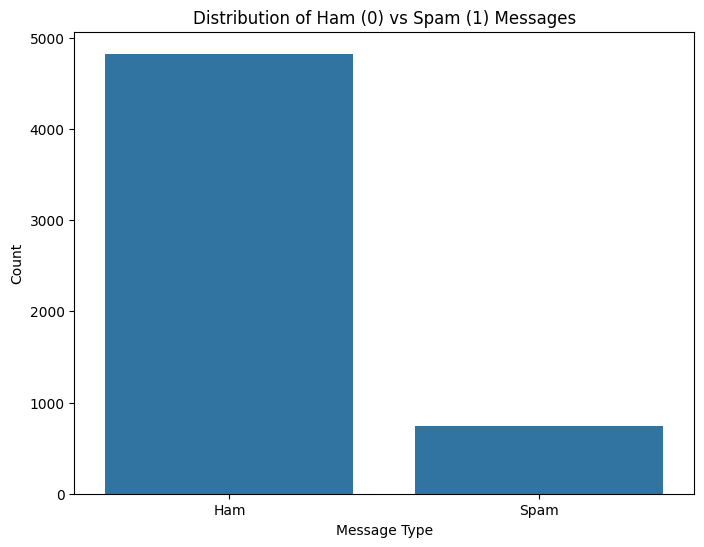

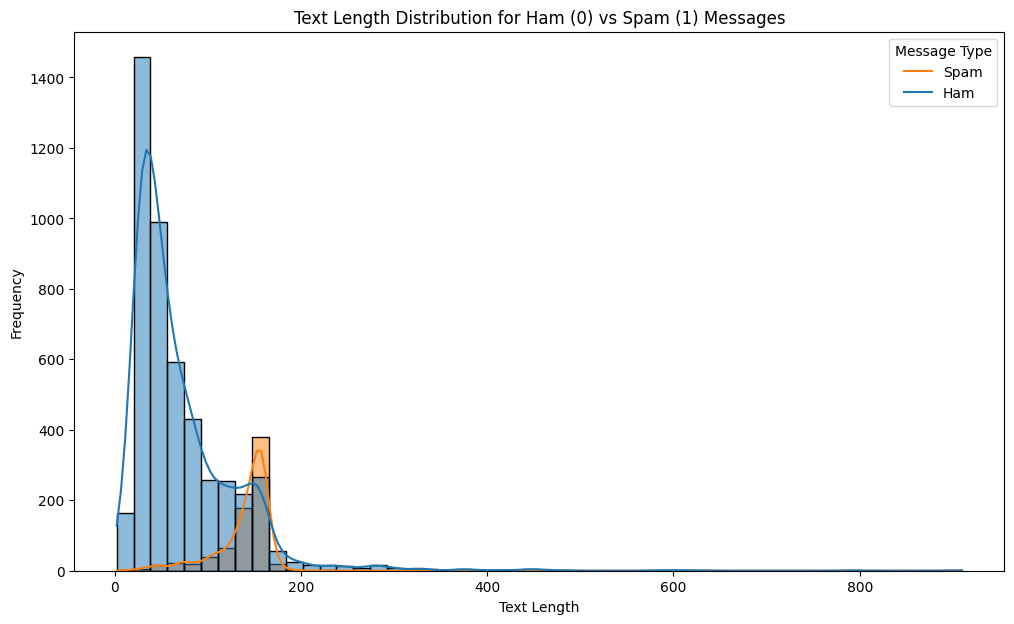

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Ham vs Spam
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham (0) vs Spam (1) Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

# Calculate text length
df['text_length'] = df['text'].apply(len)
# Text Length Distribution for Ham vs Spam
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Text Length Distribution for Ham (0) vs Spam (1) Messages')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(title='Message Type', labels=['Spam', 'Ham'])
plt.show()

In [56]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
df["clean_text"] = df["text"].apply(preprocess_text)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]
print(X.shape)
# so the number of the features is 7062

(5572, 7855)


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)}

In [60]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1-score", ascending=False)
results_df

,Accuracy,Precision,Recall,F1-score
Linear SVM,0.975785,0.976744,0.840000,0.903226
Random Forest,0.973991,1.000000,0.806667,0.892989
Decision Tree,0.961435,0.849673,0.866667,0.858086
Naive Bayes,0.965022,1.000000,0.740000,0.850575
Logistic Regression,0.948879,0.960396,0.646667,0.772908


In [61]:
import joblib
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print("Best model:", best_model_name)
joblib.dump(preprocess_text, "preprocessor.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(best_model, "model.pkl")

Best model: Linear SVM


['model.pkl']

In [65]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

# Initialize FastAPI
app = FastAPI()
# Load saved objects
model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")
preprocess = joblib.load("preprocessor.pkl")

# Define request schema
class TextInput(BaseModel):
    text: str

# Home route
@app.get("/")
def home():
    return {"message": "Spam Detection API is running"}

# Prediction endpoint
@app.post("/predict")
def predict(data: TextInput):

    clean_text = preprocess(data.text)
    vector = vectorizer.transform([clean_text])
    prediction = model.predict(vector)[0]
    label = "spam" if prediction == 1 else "ham"
    return {"prediction": label}


SyntaxError: invalid syntax (1223348983.py, line 1)

# Step 8 — Build a FastAPI Model Service

Students will create a simple **prediction API**.

### Goal

Send text → receive predicted class.

---

## Project Structure

Suggested folder structure:

```
nlp_project
│
├── model.pkl
├── vectorizer.pkl
├── preprocess.pkl
│
├── app.py
└── notebook.ipynb
```

---

## FastAPI Implementation Hints

Steps:

1. Load saved objects
2. Create API endpoint
3. Accept input text
4. Apply preprocessing
5. Vectorize text
6. Predict label
7. Return prediction

---

### Example Endpoint

`POST /predict`

Input:

```
{
  "text": "Free money!!! Click this link"
}
```

Output:

```
{
  "prediction": "spam"
}
```

---

### Run the API

Students should run:

```
uvicorn app:app --reload
```

Then open:

http://127.0.0.1:8000/docs

to test the API using Swagger UI.


# Bonus Tasks (Optional)

Students can extend the project by:

- Creating a scikit-learn Pipeline
- Performing hyperparameter tuning
- Adding model comparison plots
- Deploying the API with Docker
- Building a simple Streamlit UI
